In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True )

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split
x=data.drop(["median_house_value"],axis=1)
y=data["median_house_value"]

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [9]:
train_data=x_train.join(y_train)

In [10]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
5066,-118.30,33.99,44.0,1458.0,326.0,1159.0,283.0,1.1645,<1H OCEAN,98200.0
6931,-118.08,34.01,33.0,1091.0,233.0,890.0,226.0,2.7679,<1H OCEAN,176400.0
14070,-117.12,32.76,43.0,2336.0,644.0,1203.0,614.0,2.3594,NEAR OCEAN,127800.0
12625,-121.54,38.49,6.0,9104.0,1535.0,3759.0,1481.0,5.1442,INLAND,174500.0
10309,-117.74,33.89,4.0,37937.0,5471.0,16122.0,5189.0,7.4947,<1H OCEAN,366300.0
...,...,...,...,...,...,...,...,...,...,...
7267,-118.22,33.98,34.0,2283.0,809.0,3032.0,832.0,2.4387,<1H OCEAN,175000.0
13849,-117.30,34.52,34.0,4493.0,838.0,2335.0,779.0,3.1635,INLAND,74300.0
3602,-118.49,34.22,30.0,1756.0,314.0,899.0,288.0,5.0325,<1H OCEAN,238200.0
4932,-118.26,34.00,27.0,1611.0,479.0,1457.0,458.0,0.8941,<1H OCEAN,91900.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

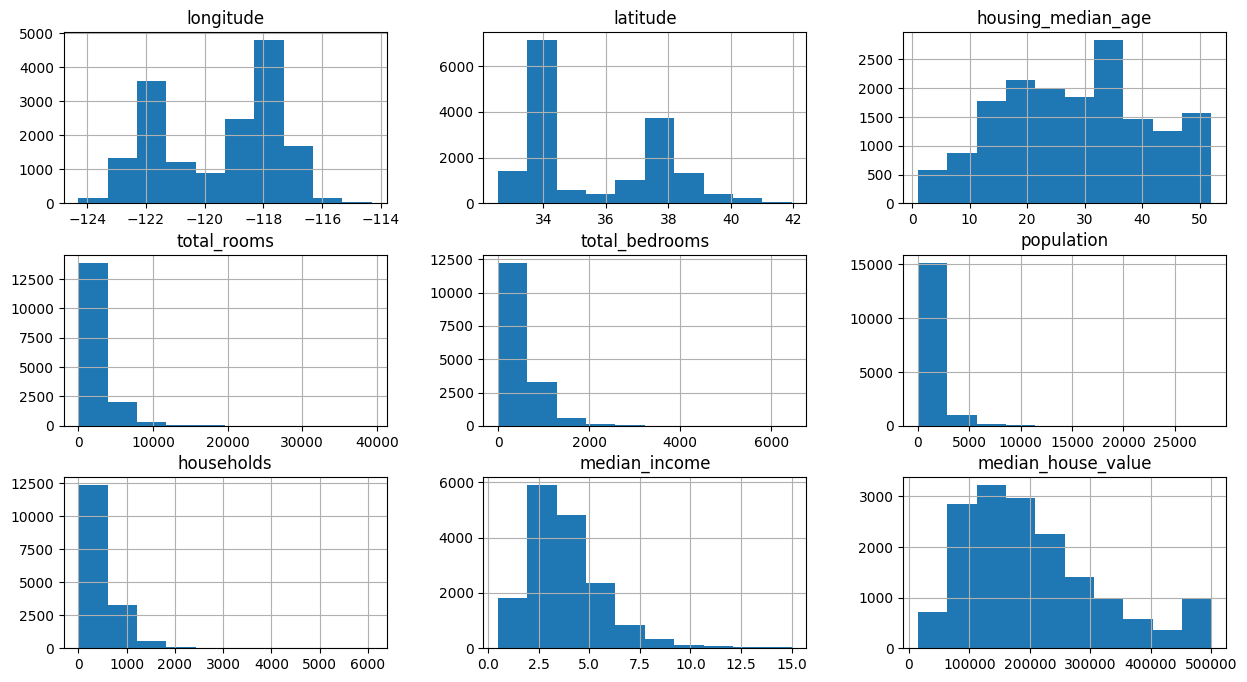

In [11]:
train_data.hist(figsize=(15,8))

<Axes: >

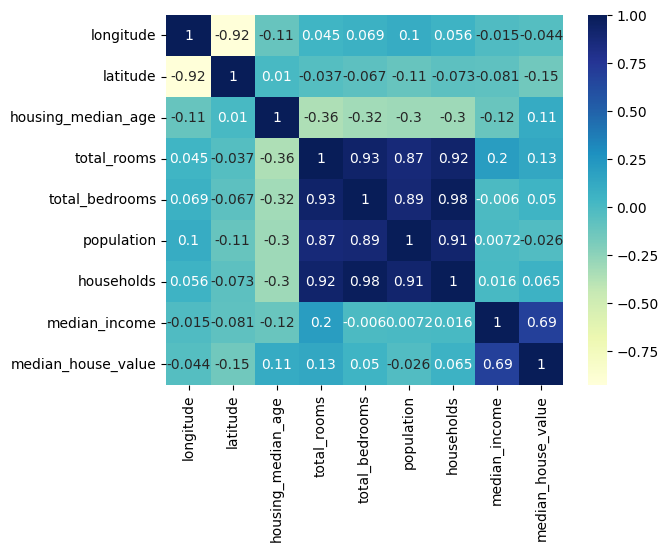

In [12]:
corr = train_data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu")

In [13]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

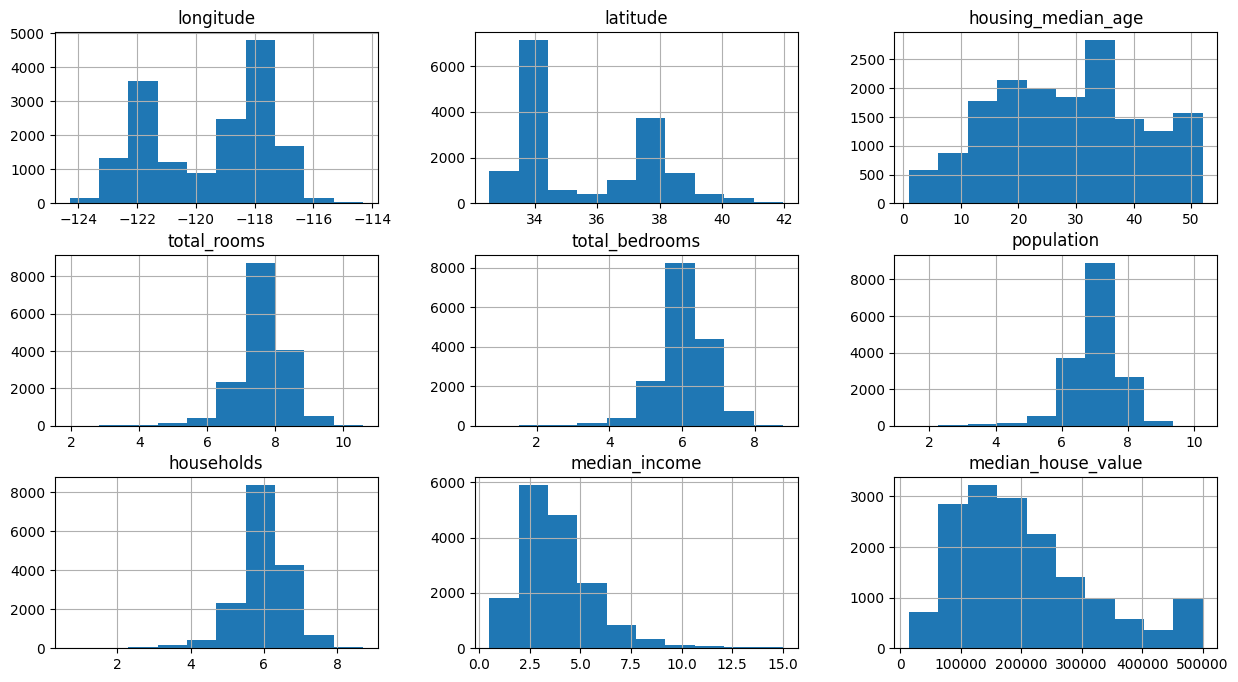

In [14]:
train_data.hist(figsize=(15,8))

In [15]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)

In [16]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
5066,-118.30,33.99,44.0,7.285507,5.789960,7.056175,5.648974,1.1645,98200.0,True,False,False,False,False
6931,-118.08,34.01,33.0,6.995766,5.455321,6.792344,5.424950,2.7679,176400.0,True,False,False,False,False
14070,-117.12,32.76,43.0,7.756623,6.469250,7.093405,6.421622,2.3594,127800.0,False,False,False,False,True
12625,-121.54,38.49,6.0,9.116579,7.336937,8.232174,7.301148,5.1442,174500.0,False,True,False,False,False
10309,-117.74,33.89,4.0,10.543709,8.607399,9.688002,8.554489,7.4947,366300.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7267,-118.22,33.98,34.0,7.733684,6.697034,8.017308,6.725034,2.4387,175000.0,True,False,False,False,False
13849,-117.30,34.52,34.0,8.410498,6.732211,7.756195,6.659294,3.1635,74300.0,False,True,False,False,False
3602,-118.49,34.22,30.0,7.471363,5.752573,6.802395,5.666427,5.0325,238200.0,True,False,False,False,False
4932,-118.26,34.00,27.0,7.385231,6.173786,7.284821,6.129050,0.8941,91900.0,True,False,False,False,False


<Axes: xlabel='latitude', ylabel='longitude'>

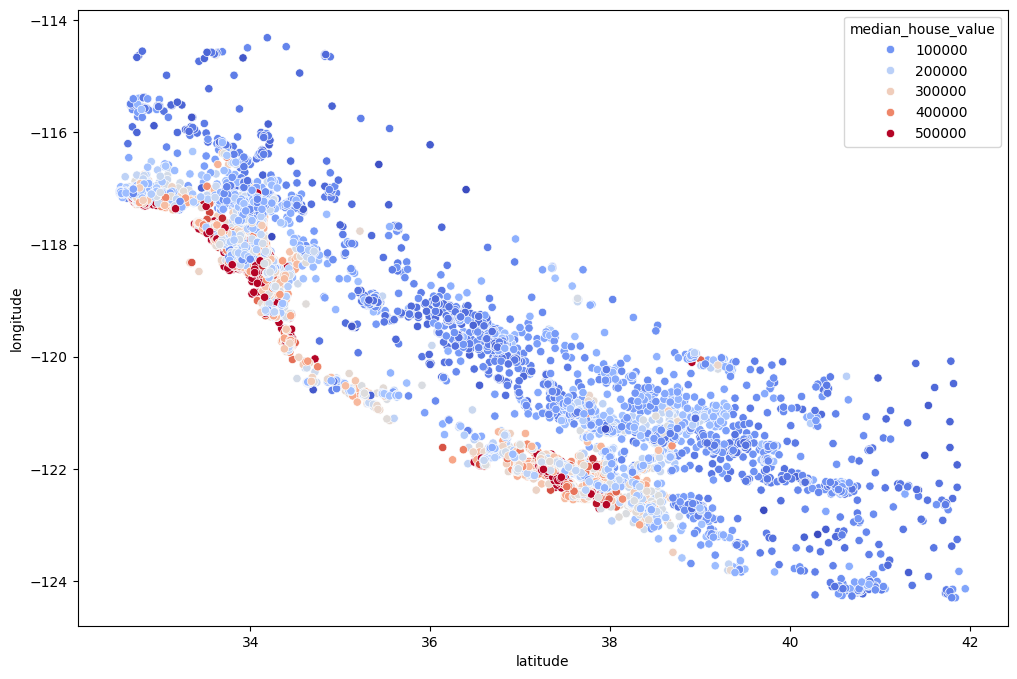

In [17]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [18]:
train_data["bedroom_ratio"] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

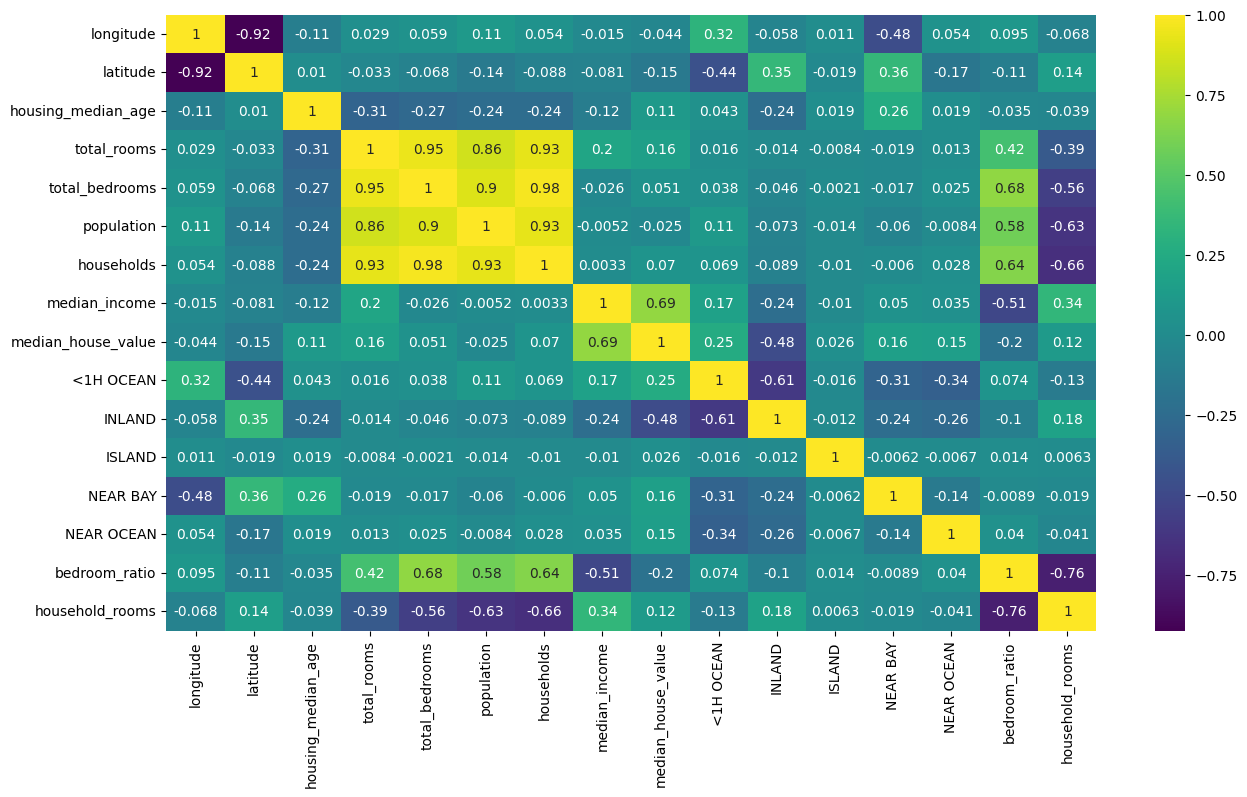

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="viridis")

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train, y_train = train_data.drop(["median_house_value"], axis=1), train_data["median_house_value"]
x_train_s = scaler.fit_transform(x_train)

reg = LinearRegression()
reg.fit(x_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
test_data = x_test.join(y_test)
test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)
test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)
test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [22]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [ ]:
x_test_s=scaler.transform(x_test)

In [ ]:
test_data

In [ ]:
 reg.score(x_test_s,y_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(x_train_s,y_train)

In [ ]:
forest.score(x_test_s,y_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True)

grid_search.fit(x_train_s, y_train)

In [ ]:
grid_search.best_estimator_